In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [3]:
df = pd.read_csv("/content/cleaned_spotify_small.csv")

print(df.head())

   Unnamed: 0  track_id  artists  album_name  track_name  popularity  \
0   -1.732036     62846    10357        8100       11741    1.782627   
1   -1.732005     55668     3287       14796       22528    0.975633   
2   -1.731975     19766    12397       39162       60774    1.065299   
3   -1.731944     77942    14839        8580        9580    1.692961   
4   -1.731914     68242     5255       16899       25689    2.186125   

   duration_ms  explicit  danceability    energy  ...  loudness      mode  \
0     0.024575     False      0.629244 -0.717148  ...  0.300828 -1.326281   
1    -0.730859     False     -0.845908 -1.889980  ... -1.784744  0.753988   
2    -0.160332     False     -0.742186 -1.122669  ... -0.293288  0.753988   
3    -0.243214     False     -1.733304 -2.312994  ... -2.039252  0.753988   
4    -0.271919     False      0.295030 -0.788711  ... -0.282750  0.753988   

   speechiness  acousticness  instrumentalness  liveness   valence     tempo  \
0     0.551848     -0.85

In [4]:
features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

X = df[features]

y = df['popularity']

In [5]:
X = X.fillna(X.median())

y = y.fillna(y.median())

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (4000, 9)
Testing Shape: (1000, 9)


In [7]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [8]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[ 0.02557391 -0.33654806 -0.24783318 -0.29643613 -0.35014761  0.49269265
  0.47693357 -0.11812838 -0.48115527  0.19575699]


In [9]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)

print("Mean Squared Error:", mse)

print("R2 Score:", r2)

Mean Absolute Error: 0.8949588156386192
Mean Squared Error: 1.167644633674597
R2 Score: 0.05445028676500019


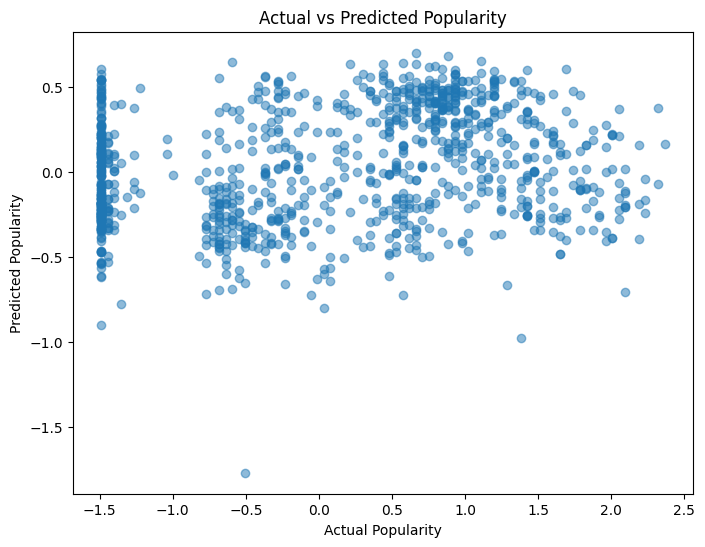

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Popularity")

plt.ylabel("Predicted Popularity")

plt.title("Actual vs Predicted Popularity")

plt.show()

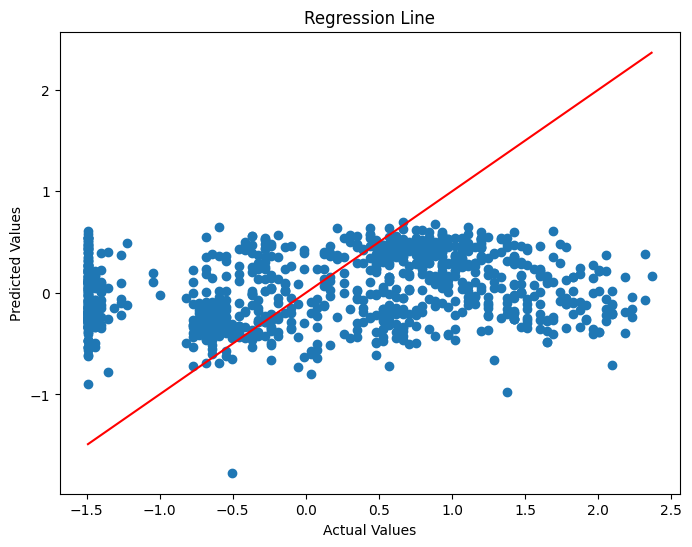

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r'
)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Regression Line")

plt.show()

In [12]:
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
})

print(coefficients)

            Feature  Coefficient
0      danceability     0.008346
1            energy    -0.122269
2          loudness     0.016937
3       speechiness    -0.206406
4      acousticness     0.049376
5  instrumentalness    -0.053600
6          liveness     0.003061
7           valence    -0.182100
8             tempo    -0.019014
